# Work Planning Prototype

**Background**: In our previous notebooks, we have a collection of techniques for performing, allocating, and analyzing our work. We anticipate that the scope of work will be greater than our hardware's ability to complete in a single charge. We should therefore carefully plan the work we aim to do in advance of arriving at a work site so that we come much more prepared.


Perhaps we follow a plan like:
- Prepare region image
    - Consolidate to single geotiff
    - Re-project CRS
    - Filter, smooth, simplify, downsample
- Parition region into manageable pieces
    - Call them "work areas/sites/plots", e.g. 1/2 acre spaces
- Segmentation & masking?
- Plan macro/micro routes
    - Macro: 1/2 acre work spaces
    - Micro: route between plants in a work space
- Execute? Store execution results? Analyze performance?


## Prepare Region Image

- Consolidate to single geotiff
- Reproject CRS
- Image pre-processing

In [1]:
import sys
from pathlib import Path

# Add the parent directory to the Python path
# So we can find local modules e.g. "plant_search"
sys.path.append(str(Path.cwd().parent))

# file_path = 'input/ESPG-4326-orthophoto.tif'
# file_path = 'input/MADRID_RGB.tif'
# file_path = '../input/aerial-trees.jpg'

# file_path = '../input/DJI_0010.JPG'
# file_path = '../input/DJI_0015.JPG'
# file_path = '../input/DJI_0093.JPG'
# file_path = '../input/DJI_0119.JPG'

# file_path = '../input/IGNORE_Brewster-ortho.tif'
file_path = '../input/IGNORE_Brewster-2024-all-orthophoto-UTM-32613.tif'


Image CRS - EPSG:32613


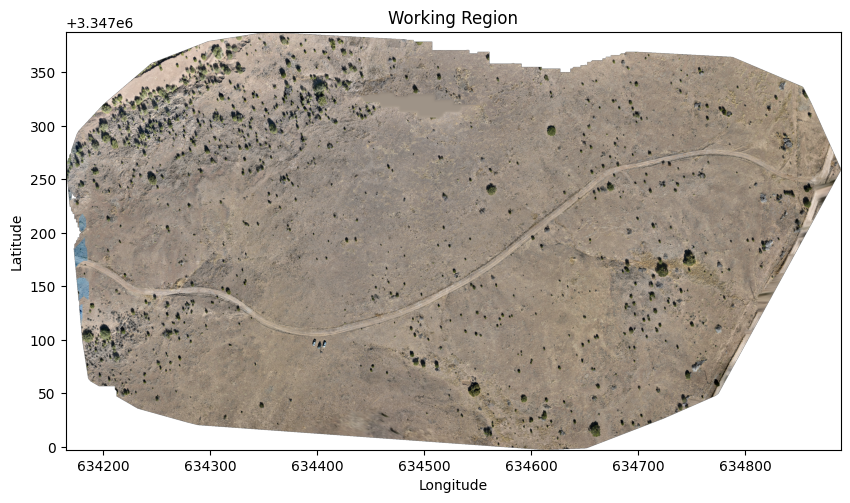

Image dimensions: (1768, 3280, 4)


In [2]:
from plant_search.load_image import load_image, plot_image, plot_geotiff

ds = 4 # downscale ratio

image, transform, bounds, image_crs = load_image(file_path)

# We have a georeferenced image
if image is not None and transform and bounds:
    original_image_shape = image.shape
    image = image[::ds, ::ds]
    # Calculate extent in geographic coordinates
    image_extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
    plot_geotiff(image, transform, bounds, "Working Region")

# We have image, but not georeferenced
elif image is not None and bounds:
    original_image_shape = image.shape
    height, width = image.shape[:2]
    image_extent = (0, width, 0, height)
    image = image[::ds, ::ds]
    plot_image(image, "Original Image")

print(f"Image dimensions: {image.shape}")

## Parition Region
- Create outline polygon of full work region
    - Simplify geometry for faster execution
- Divide full region into working areas

In [3]:
region_crs = 32613 # Use this everywhere for consistency

simplification_tolerance = 5

# Convert target area to square meters
target_area_acres = 0.5
# target_area_acres = 1.5
# target_area_acres = 2.5

max_iterations = 15

Reached maximum iterations without full convergence.


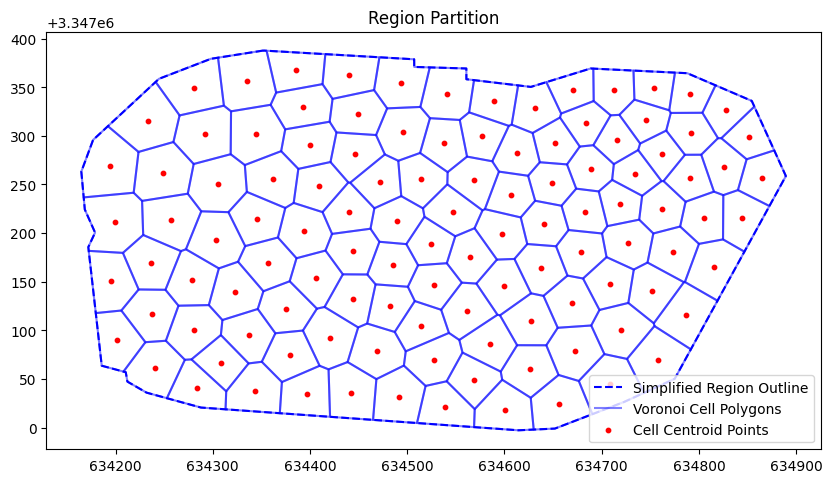

In [4]:
from plant_search.region_partition import (
    extract_region_contour,
    simplify_polygon,
    generate_voronoi_partition,
    centroidal_voronoi_tessellation,
)
import matplotlib.pyplot as plt
import geopandas as gpd


region_contour_gpd = extract_region_contour(file_path)
contour_gdf_projected = region_contour_gpd.to_crs(epsg=region_crs)  # Example: UTM Zone 14N
simplified_polygon = simplify_polygon(contour_gdf_projected.geometry.iloc[0], simplification_tolerance)

target_area_sqm = target_area_acres * 4046.86
num_points = int(simplified_polygon.area / target_area_sqm)

# voronoi_gdf, points_gdf = generate_voronoi_partition(simplified_polygon, num_points)
cell_gdf = centroidal_voronoi_tessellation(simplified_polygon, num_points, max_iterations)


fig, ax = plt.subplots(figsize=(10, 10))

gpd.GeoDataFrame({"geometry": [simplified_polygon]}).boundary.plot(ax=ax, color="blue", linestyle="--", label="Simplified Region Outline")
cell_gdf.boundary.plot(ax=ax, color="blue", alpha=0.5, label="Voronoi Cell Polygons")
cell_gdf.set_geometry('cell_centroid').plot(ax=ax, color="red", markersize=10, label="Cell Centroid Points")

plt.legend()
plt.title("Region Partition")
plt.show()

## Macro Planning

### Background

This section is predicated on a number of assumptions about the nature of our work.

**Assumptions:**
-  Our greatest priority is to minimize total time on job, and therefore operational expense
    - Battery charging duration is greatest time bottleneck
    - Travel distance and time is secondary efficiency concern
-  We cannot complete our work areas in a single trip (on a single battery charge)
    - ⇒ Traveling Salesman Problem solution is insufficient (not contiguous, single path)
    - "Stopping" and "resuming" TSP to recharge is inefficient
        - Adds unaccounted overhead with returns
- A high-level macro-plan simplification of our work area is a useful and representative approximation of our work area
- The presented solution will be useful and representative of future work areas

**Problem Approach:**
What problem are we trying to solve?

We want to plan a number of routes such that:
1. We have the fewest reasonable number of routes (minimal turn-around)
2. Each route uses almost all of the battery (no wasted capacity)
3. Each route uses battery efficiently (implied by 1, energy expended working, not in transit)
4. Routes do not interfere with efficiency of other routes (2,3)
    - Each route is efficient individually, while together all routes are efficient
    - Implies simultaneous solving


### Intro

Since we have divided our working region into smaller, more manageable portions, we can now plan our approach. We will use our cells to help measure area completion and divide work areas more efficiently. 

This section is concerned with:
- clustering of cells into trips
- prioritization of cells
- global trip efficiency
    - A.K.A. Multi-Trip Routing Problem (MTRP)
- Completion efficiency

Our planning inputs:
- cells and centroids
- base station location
    - where drones launch and land
- drone battery range
- target density per cell

### Simple Macro Routing
We want to compute routes which are efficient and cover our work area in the fewest total trips. This is known as a **Vehicle Routing Problem** (VRP), in which our only dimension of constraint is the range of our drone. 

In this section we  will generate efficient routes to visit the centroid of every cell in our working area such that the routes meet our above requirements. Of course, our greater goal is not to just visit every cell in our area. Later, we will account for the work (number, density, distance of targets) in each cell.


Parameters:
- `max_distance`: The maximum range of the drone, in meters. We will try to find trips as close to this length as possible to use up the full battery.
- `distance_slack`: Represents amount of "slack" we can have in a route without incurring penalty. We will rarely ever find a route at *exactly* 'max_distance'. This variable sets how permissive we can be for these routes.
 - `distance_slack_penalty`: Multiplier for penalty incurred when a route is less than a lower bound distance. We set the soft lower bound to 'max_distance' and the multiplier high to encourage routes to get as close to full length as possible.
 - `slack_routes`: The number of routes we are *not* going to try to force to the max distance. We will use this to clean up "remainder" routes/cells after full-length routes are generated.

In [5]:
max_distance = 800  # Max distance per trip (meters)
distance_slack = 20
distance_slack_penalty = 10_000
slack_routes = 5
num_vehicles = 14

In [6]:
from shapely.geometry import Point
import geopandas as gpd

# Base station location
base_station_coords = (634500,3347200)
base_station_gdf = gpd.GeoDataFrame(
    [{'geometry': Point(base_station_coords)}],
    crs=region_crs
)

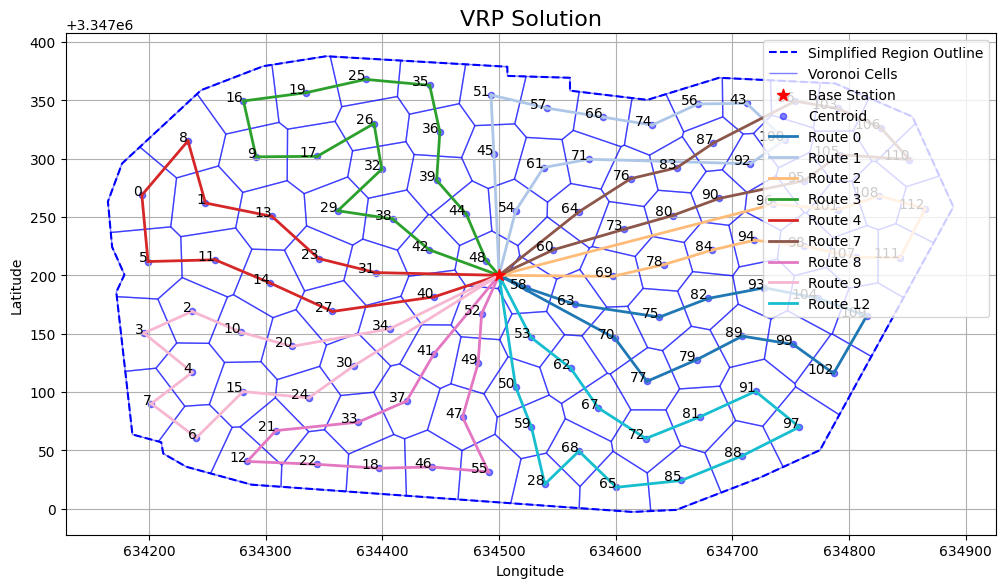

In [7]:
from macro_planning.trip_routing import (
    create_distance_matrix,
    solve_basic_vrp,
)
from macro_planning.visualize_routing import plot_vrp_solution

distance_matrix = create_distance_matrix(cell_gdf, base_station_gdf) # excluding intra-workload cost
num_cells = len(distance_matrix)-1 # Number of stops
# num_vehicles = math.ceil(math.sqrt(num_cells)) + 1

# print(f"num_cells: {num_cells}")
# print(f"num_vehicles: {num_vehicles}")

data = {
    "core": {
        "distance_matrix": distance_matrix,
        "num_vehicles": num_vehicles,
        "depot_index": num_cells,
        "max_distance": max_distance,
        "distance_slack": distance_slack,
        "distance_slack_penalty": distance_slack_penalty,
        "slack_routes": slack_routes
    }
}

print_routes = False # Set to True to see individual route statistics
routes = solve_basic_vrp(data, print_routes)

# If solved, plot solution
plot_vrp_solution(cell_gdf, distance_matrix, simplified_polygon, base_station_gdf, routes)


### Region Target Search

If not computationally prohibitive, we can perform our target search on the full working area. Even at a much lower resolution, this can help us determine the total number of target plants in each cell, and ultimately on each route.

This is just using the CV search techniques we explored earlier.

In [8]:
from plant_search.image_preprocess import (
    generate_target_mask,
    correct_binary_mask,
    identify_targets,
)
import rasterio

# binary_mask = generate_target_mask(image) # Generate

# Load mask the easy way
binary_mask_path = "../outputs/region_binary_mask.tif"
with rasterio.open(binary_mask_path) as src:
    binary_mask = src.read(1)  # Read the first band
    bin_transform = src.transform  # Get the affine transform
    bin_crs = src.crs  # Get the CRS

full_binary_mask = correct_binary_mask(binary_mask, original_image_shape)
targets_gdf = identify_targets(full_binary_mask, transform)


del full_binary_mask # Gimme back my RAM
print(f"Number of targets (detected plants): {len(targets_gdf)}")

Number of targets (detected plants): 606


In [9]:
# # Instead of re-computing, save to image
# binary_mask_scaled = (binary_mask * 255).astype("uint8")

# with rasterio.open(file_path) as src:
#     image_region_crs = src.crs

# # Save the georeferenced binary mask with the correct scaling
# with rasterio.open(
#     "../outputs/region_binary_mask.tif",
#     "w",
#     driver="GTiff",
#     height=binary_mask.shape[0],
#     width=binary_mask.shape[1],
#     count=1,
#     dtype="uint8",
#     crs=image_region_crs,
#     transform=transform,
# ) as dst:
#     dst.write(binary_mask_scaled, 1)

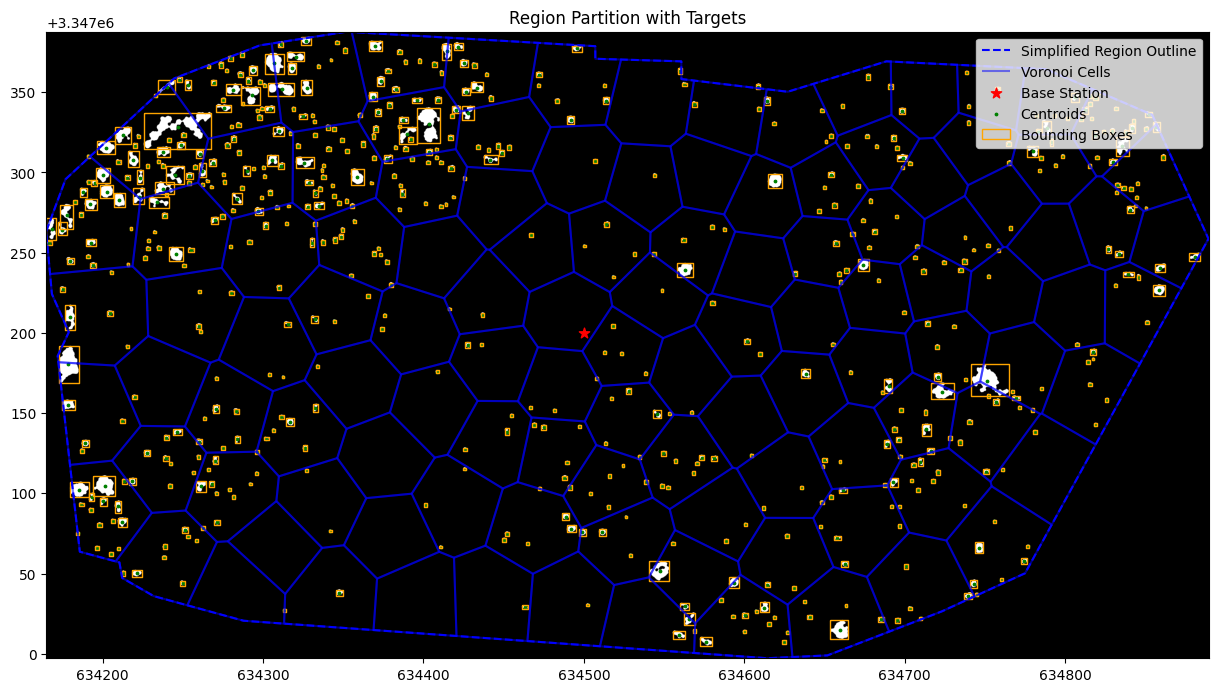

In [10]:
import matplotlib.patches as mpatches

# Display identified targets
fig, ax = plt.subplots(figsize=(15, 15))
# ax.imshow(image, extent=image_extent, alpha=0.8) # Display original image
ax.imshow(binary_mask, extent=image_extent, cmap='gray') # Show targets binary mask

# Region outline, cells, centroids
gpd.GeoDataFrame({"geometry": [simplified_polygon]}).boundary.plot(ax=ax, color="blue", linestyle="--", label="Simplified Region Outline")
cell_gdf.boundary.plot(ax=ax, color="blue", alpha=0.5, label="Voronoi Cells") # Region cells
# cell_gdf.set_geometry('cell_centroid').plot(ax=ax, color="red", markersize=10, label="Cell Centroids")
base_station_gdf.plot(ax=ax, color='red', markersize=60, marker='*', label='Base Station')

targets_gdf.plot(ax=ax, color='green', markersize=3, label='Centroids') # Plot targets centroids
targets_gdf.set_geometry('bounding_box').plot(ax=ax, edgecolor='orange', facecolor='none', linewidth=1.0) # Plot targets bounding boxes

# Fix legend for bounding boxes
handles, labels = ax.get_legend_handles_labels()
bounding_box_patch = mpatches.Patch(edgecolor='orange', facecolor='none', label='Bounding Boxes') # Add a custom handle for the bounding boxes
handles.append(bounding_box_patch)
labels.append('Bounding Boxes')

ax.legend(handles, labels, loc='upper right')
# plt.legend()
plt.title("Region Partition with Targets")
plt.show()

### Calculate Cell Densities

First-pass system to determine:
- Number of targets in each cell
- Distance to traverse all targets in each cell

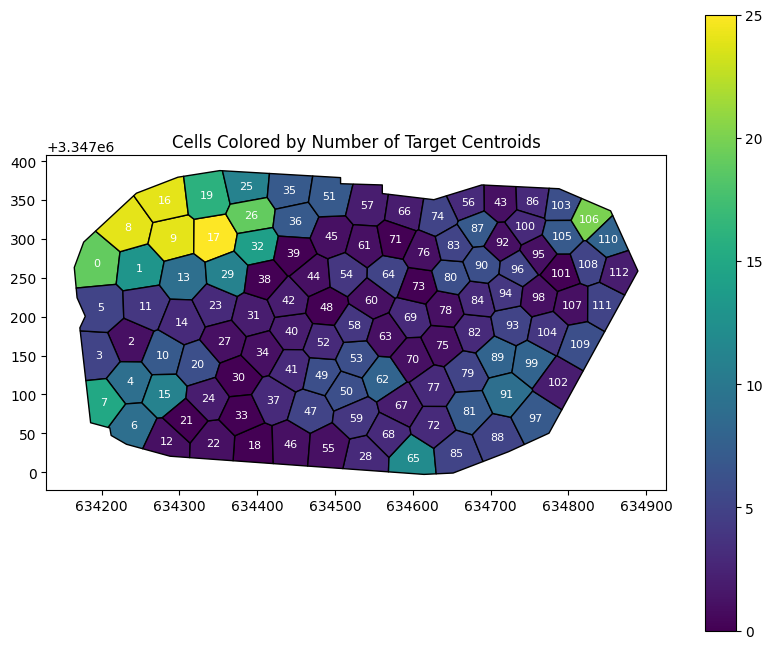

In [11]:
from plant_search.macro_planning import (
    calculate_cell_workloads,
    plot_cells_with_targets,
    plot_cells_ids,
)


calculate_cell_workloads(cell_gdf, targets_gdf) # In-place updates

# Ensure base station is a valid Point geometry

# Compute distance from each cell centroid to the base station
base_station_point = base_station_gdf.geometry.iloc[0]
cell_gdf['home_distance'] = cell_gdf['cell_centroid'].distance(base_station_point)
# cell_gdf['total_workload'] = cell_gdf['intra_workload'] + (2 * cell_gdf['home_distance'])

# Visualize cell workloads
# plot_cells_with_targets(cell_gdf)
plot_cells_ids(cell_gdf)

# targets_gdf
# joined
# cell_gdf

### Target-Compensated Trip Routing

In our previous section, we solved for routes which efficiently covered every cell in our working area. However, this assumed that the only cost associated with each cell was the distance to its centroid. 

To make our approximation more effective, we will also want to account for the distance *within* each cell that the drone will take to address all of the targets. We will add `intra_workload` to our distance matrix to approximate this distance.

In [20]:
t_max_distance = 1000  # Max distance per trip (meters)
t_distance_slack = 100
t_distance_slack_penalty = 10_000
t_slack_routes = 5
t_num_vehicles = 30

Objective Value: 16915
Max allowed distance: 1000

Vehicle Details:

Vehicle 0:
	Route for vehicle 0:
	   113 -> 113
	Cumulative Distance: 0
	Slack: 1000
	Route Distance: 0

Vehicle 1:
	Route for vehicle 1:
	   113 -> 113
	Cumulative Distance: 0
	Slack: 1000
	Route Distance: 0

Vehicle 2:
	Route for vehicle 2:
	   113 ->  33 ->  21 ->  7 ->  4 ->  10 ->  27 -> 113
	Cumulative Distance: 1000
	Slack: 0
	Route Distance: 993

Vehicle 3:
	Route for vehicle 3:
	   113 ->  92 ->  106 ->  108 ->  101 ->  96 ->  73 -> 113
	Cumulative Distance: 1000
	Slack: 0
	Route Distance: 968

Vehicle 4:
	Route for vehicle 4:
	   113 ->  14 ->  11 ->  5 ->  3 ->  2 -> 113
	Cumulative Distance: 1000
	Slack: 0
	Route Distance: 941

Vehicle 5:
	Route for vehicle 5:
	   113 ->  16 ->  19 ->  36 ->  44 -> 113
	Cumulative Distance: 1000
	Slack: 0
	Route Distance: 976

Vehicle 6:
	Route for vehicle 6:
	   113 -> 113
	Cumulative Distance: 0
	Slack: 1000
	Route Distance: 0

Vehicle 7:
	Route for vehicle 7:
	   113 ->

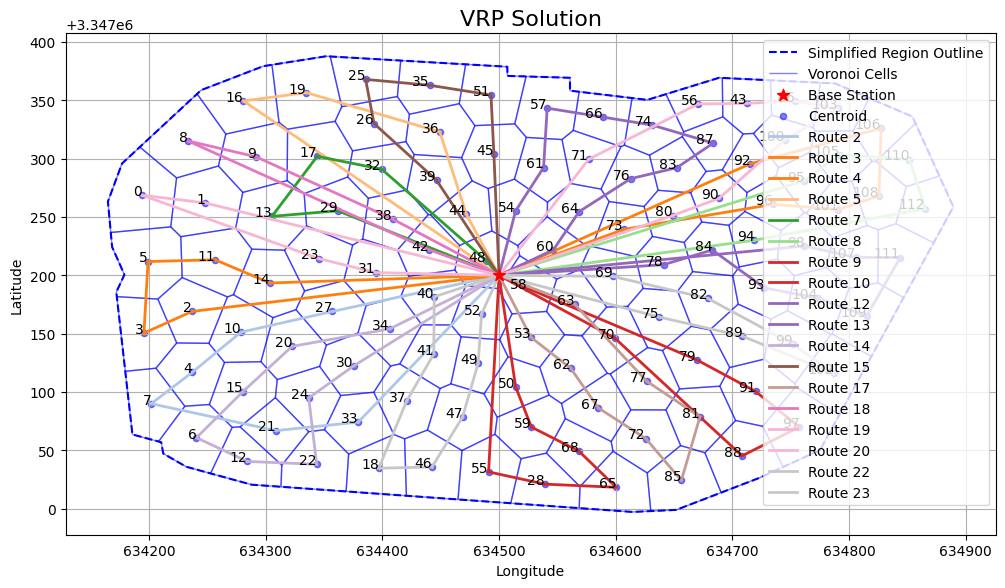

In [21]:
from macro_planning.trip_routing import (
    create_distance_matrix,
    solve_basic_vrp,
)
from macro_planning.visualize_routing import (
    plot_vrp_solution,
    distance_matrix_heatmap,
    distance_matrix_plot_distances
)

compensate_for_targets = True
t_distance_matrix = create_distance_matrix(cell_gdf, base_station_gdf, compensate_for_targets) # excluding intra-workload cost
t_num_cells = len(t_distance_matrix)-1 # Number of stops
# num_vehicles = math.ceil(math.sqrt(num_cells)) + 1

# distance_matrix_heatmap(t_distance_matrix)
# distance_matrix_plot_distances(cell_gdf, t_distance_matrix, simplified_polygon, base_station_gdf)

# print(f"num_cells: {num_cells}")
# print(f"num_vehicles: {num_vehicles}")

target_data = {
    "core": {
        "distance_matrix": t_distance_matrix,
        "num_vehicles": t_num_vehicles,
        "depot_index": t_num_cells,
        "max_distance": t_max_distance,
        "distance_slack": t_distance_slack,
        "distance_slack_penalty": t_distance_slack_penalty,
        "slack_routes": t_slack_routes
    }
}

print_routes = True # Set to True to see individual route statistics
target_routes = solve_basic_vrp(target_data, print_routes)

# If solved, plot solution
if target_routes and isinstance(target_routes, list):
    plot_vrp_solution(cell_gdf, t_distance_matrix, simplified_polygon, base_station_gdf, target_routes)


## Micro Planning

Perform image analysis on each smaller section of our greater region.